# Showcase: Infer wine country from review text

**Juan David Prada** · Data Science Summer School 2021 portfolio piece

This notebook turns one DS³ NLP lab into a short, readable case study: given only the cleaned tasting note, can a linear model recover the country of origin?

### Why this matters
In applied work the same pattern shows up everywhere — support tickets, policy documents, open-ended survey answers. You need a disciplined path from raw text → features → held-out evaluation → interpretable signals.

### Pipeline
1. Load preprocessed wine reviews (US, France, Italy, Spain)
2. Stratified train / test split
3. TF–IDF (unigrams + bigrams) + balanced logistic regression
4. Report macro-F1, confusion matrix, and top coefficients per class


## 1. Data


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

DATA = Path("../NaturalLanguageProcessing/TextClassification/wine_reviews_classification.xlsx")
df = pd.read_excel(DATA).dropna(subset=["description_cleaned", "country"])
df = df[df["country"].isin(["US", "France", "Italy", "Spain"])]

print(f"Rows: {len(df):,}")
print(df["country"].value_counts())
df[["country", "description_cleaned"]].head(3)


Rows: 20,000
    US    10774
 Italy    3963
France    3857
 Spain    1406
Name: country, dtype: int64


Class balance in this extract — France: 3857, Italy: 3963, Spain: 1406, US: 10774. Stratified splitting keeps those proportions in train and test.


## 2. Model


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df["description_cleaned"],
    df["country"],
    test_size=0.25,
    random_state=42,
    stratify=df["country"],
)

pipe = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5)),
        (
            "clf",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                solver="lbfgs",
            ),
        ),
    ]
)
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Macro-F1: {f1_score(y_test, pred, average='macro'):.3f}")


Train: 15,000 | Test: 5,000
Macro-F1: 0.880


## 3. Held-out evaluation


              precision    recall  f1-score   support

      France      0.867     0.904     0.885       964
       Italy      0.885     0.911     0.898       991
       Spain      0.722     0.909     0.805       351
          US      0.961     0.904     0.932      2694

    accuracy                          0.906      5000
   macro avg      0.859     0.907     0.880      5000
weighted avg      0.911     0.906     0.907      5000


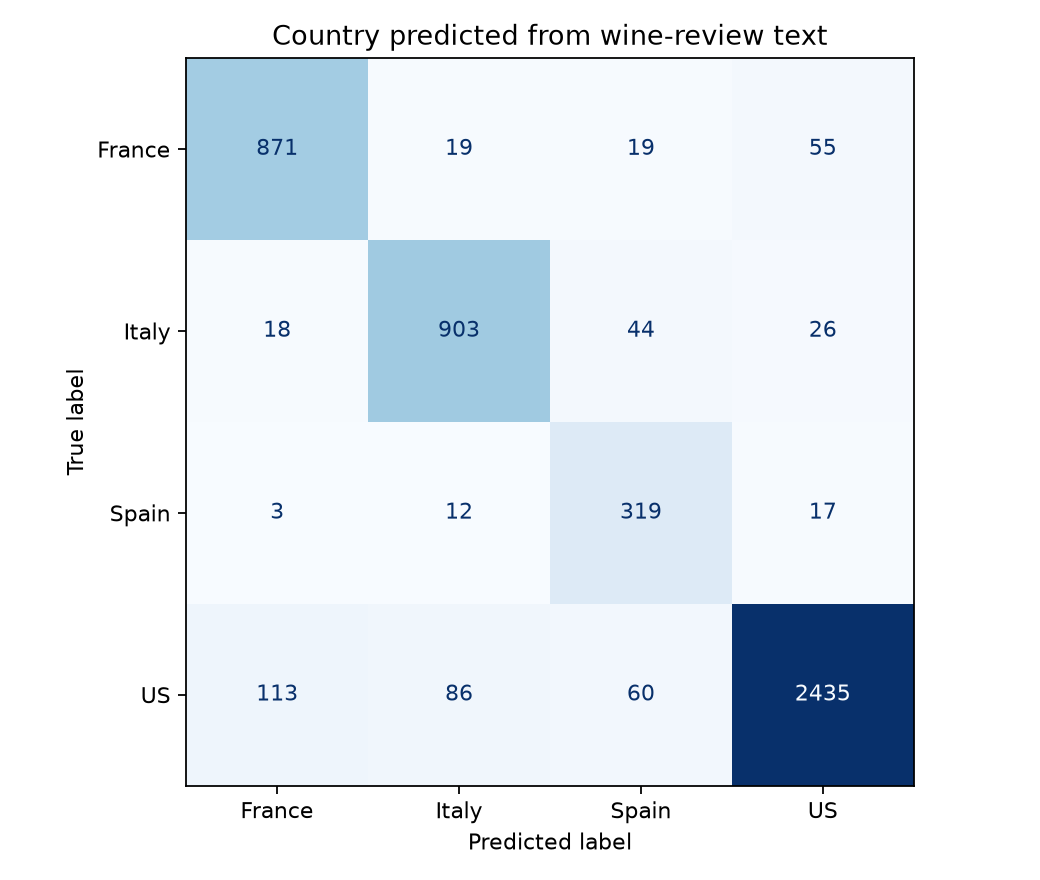

In [ ]:
print(classification_report(y_test, pred, digits=3))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, labels=sorted(y_test.unique()), cmap="Blues", colorbar=False, ax=ax
)
ax.set_title("Country predicted from wine-review text")
fig.tight_layout()
fig.savefig("figures/confusion_matrix.png", dpi=160)
plt.show()


## 4. What the model relies on

Coefficients on TF–IDF features are a blunt but useful interpretability check: do the top n-grams look like geography, grape, or tasting-culture cues?


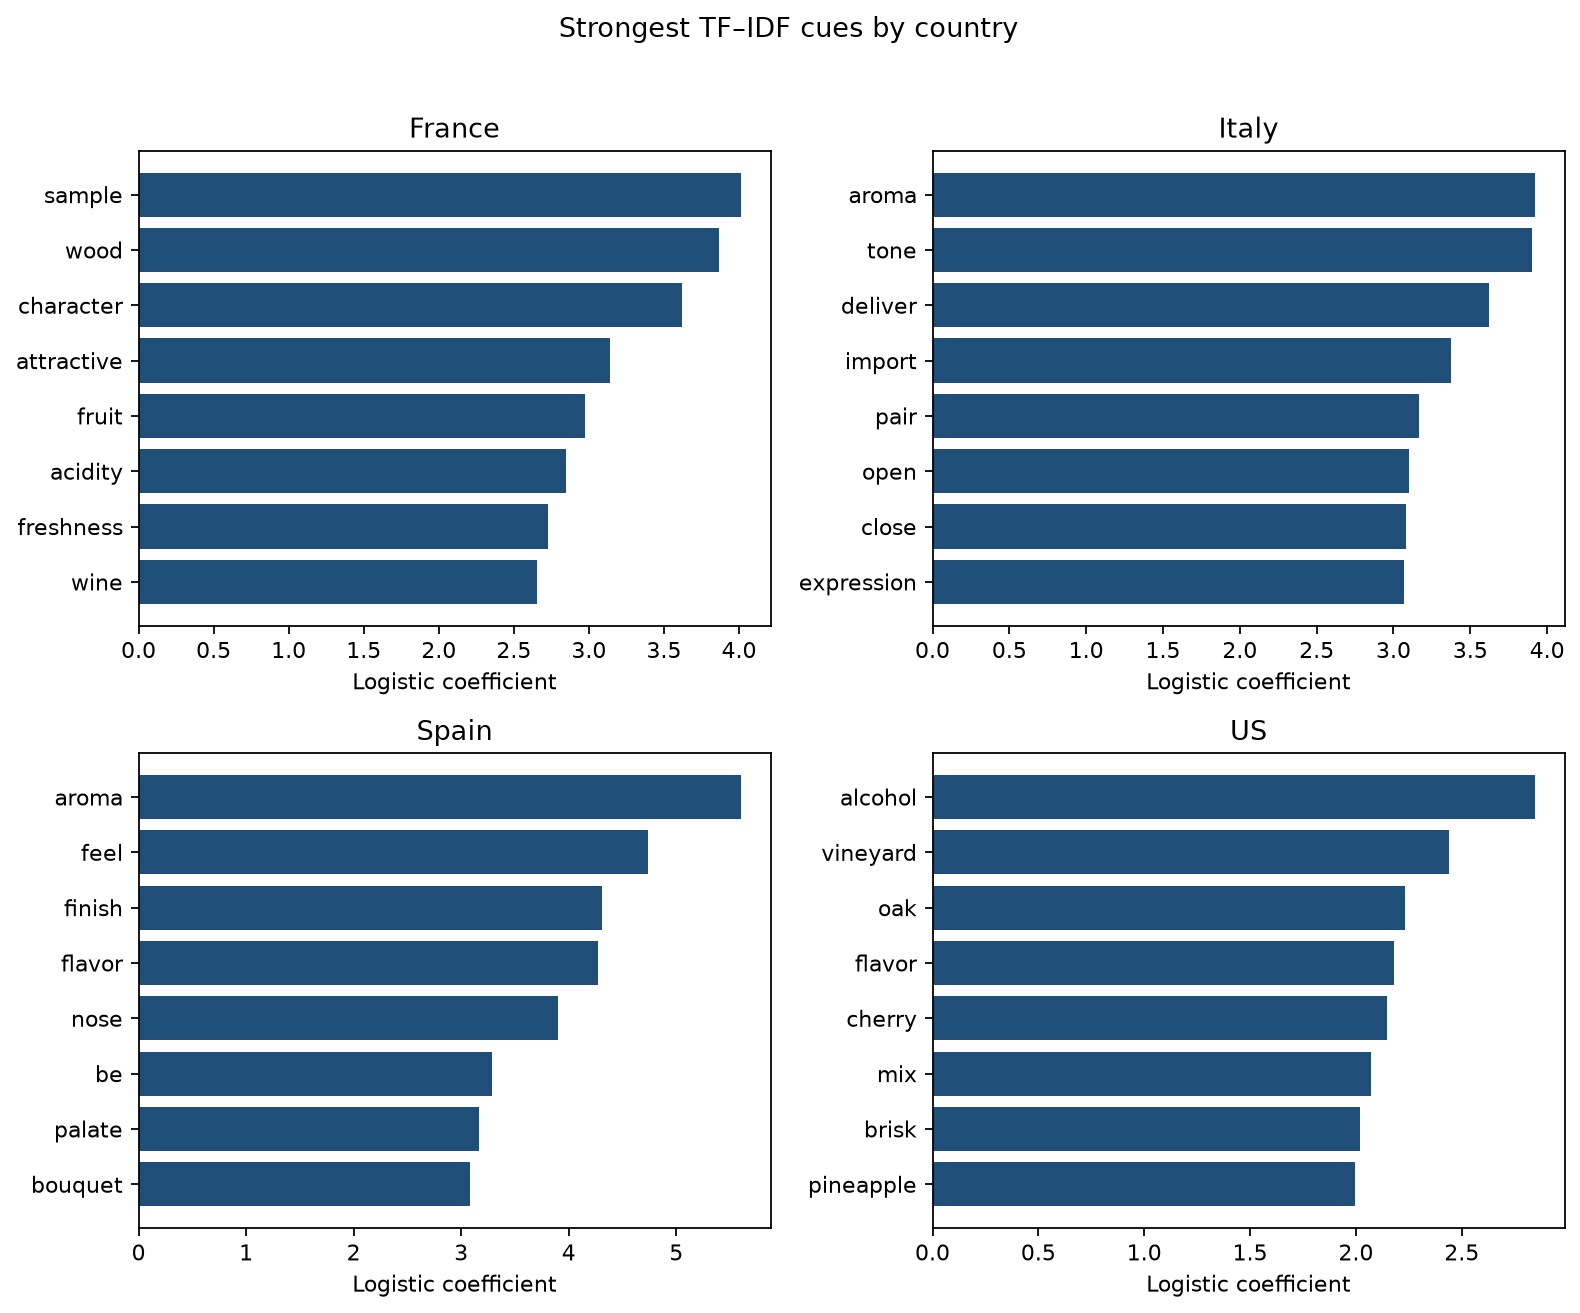

In [ ]:
vec = pipe.named_steps["tfidf"]
clf = pipe.named_steps["clf"]
terms = np.array(vec.get_feature_names_out())

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, class_idx, country in zip(axes.ravel(), range(len(clf.classes_)), clf.classes_):
    coefs = clf.coef_[class_idx]
    top_idx = np.argsort(coefs)[-8:]
    ax.barh(terms[top_idx], coefs[top_idx], color="#1f4e79")
    ax.set_title(country)
    ax.set_xlabel("Logistic coefficient")
fig.suptitle("Strongest TF–IDF cues by country", y=1.02)
fig.tight_layout()
fig.savefig("figures/top_features.png", dpi=160, bbox_inches="tight")
plt.show()


## Takeaway

- **Macro-F1 ≈ 0.88** on a stratified held-out set — strong enough to show that country signal lives in tasting language, not only in structured fields.
- The reusable pattern from DS³: **preprocess once → vectorize with a frozen vocabulary → evaluate on data the model never saw → inspect coefficients before shipping predictions**.
- Same workflow transfers to survey open-ends, news corpora, or moderation queues.

Related course materials: [`NaturalLanguageProcessing/`](../NaturalLanguageProcessing/) · [`Text2Data/`](../Text2Data/).
